# Midterm Exam (part 3) - Computational Physics I

### Deadline: Monday 13 October 2025 (by 19h00)
### Name: Mejia Perez Bady Fernadno

## Part 3. (10 points) Data analysis and visualisation (Rayleigh-Taylor instability)

The **Rayleigh-Taylor instability** occurs at the interface between two fluids of different densities when the lighter fluid is pushing the heavier fluid. Examples include the behavior of water suspended above oil in the gravity of Earth, mushroom clouds like those from volcanic eruptions and atmospheric nuclear explosions, supernova explosions in which expanding core gas is accelerated into denser shell gas.

In this problem, you will analyse a simulation of the Rayleigh-Taylor instability arising at the interface between 2 gases (one heavy and one light) in 2D. The initial condition consists of an interface separating two gases with different densities in hydrostatic balance:

$$
\rho(y) = \begin{cases}
1 & \text{for } y \le 0 \\
\eta & \text{for } y > 0
\end{cases}
\,,\qquad
p = p_0 + \rho\,y\,g
$$

where $\eta$ is the density of the gas on top in code units, $g$ is the (constant) gravity pointing in the negative $y$ direction. The system is destabilized by perturbing the vertical velocity in proximity of the interface using a single mode perturbation. The computational domain has **periodic boundary conditions** along the $X-$axis and and **reflective boundary conditions** along the $Y-$axis. The dimensions of the Cartesian domain are: $x\in[-0.5,0.5]$ and $y\in[-1.0,1.0]$ in code units.


The mono-atomic gas has an adiabatic index $\gamma=\frac{5}{3}$, and the numerical simulation produces $101$ VTK files stored in the **Rayleigh-Taylor** zipped folder: 

https://www.dropbox.com/scl/fi/j43rixdhy9upkgt76t2kl/Rayleigh_Taylor.zip?rlkey=jgliqdj4p94igr2xxna05iyax&st=h59onv8c&dl=0

which also contains the following descriptor files:

- a **units.out** file that contains the CGS normalisation values.
- a **vtk.out** file whose second column contains the times in code units.
- a **grid.out** file that contains information on the grid structure.

You can use VisIt to inspect the data. The written fields are: 

- density (rho)
- thermal pressure (prs)
- velocity_x (vx1)
- velocity_y (vx2)
- tracer (tr1), which is a pigment tracing the heavier gas on top.

**References:**

https://en.wikipedia.org/wiki/Rayleigh%E2%80%93Taylor_instability

https://iopscience.iop.org/article/10.1086/523099



**Note:**
As shown in class, the normalisation values for thermal pressure ($p_0=\rho_0\,v_0^2$) and time ($t_0=\frac{L_0}{v_0}$) can be derived from the length, velocity, and density values.


# Part A: I/O and visualisation

Within a single python notebook, carry out the following tasks:

## (a) Create a python function that reads the **units.out** file, stores the normalisation values for length, velocity, and density, calculates the normalisation values for thermal pressure and time, and returns them all into tuple objects.

The equations for normalized pressure and time are as follows:
* $ P_n=\rho_0 * v_0^2 $ (units: $\frac{g}{cm  s^2}$)
* $t_0=\frac{L_0}{v_0}$ (units: ($s$))

In [80]:
# libraries that use for this part
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

The .out files have the same format as a CSV file, so using the pandas library will be useful for this analysis.

In [81]:
def read_files(name):
    direccionton_of_disk='./Rayleigh_Taylor/'
    data=pd.DataFrame(pd.read_csv(direccionton_of_disk+name))
    pression=data.loc[0,'normalisation']*((data.loc[1,'normalisation'])**2)
    time1=data.loc[2,'normalisation']/data.loc[1,'normalisation']
    tupla=(pression,time1)
    print(f'the pressure is {pression} g/(cm*s^2) \n the time is {time1} s')
    return data,tupla

In [82]:
data1,pressure_time=read_files('units.out')

the pressure is 1.673e-14 g/(cm*s^2) 
 the time is 149600000.0 s


In [83]:
pressure_time

(np.float64(1.673e-14), np.float64(149600000.0))

## (b) Create a python function that reads the **vtk.out** file, reads the second column, and returns the times in CGS units using $t_0$ from point (a).

In [84]:
def read_vtkout(name):
    direccionton_of_disk='./Rayleigh_Taylor/'
    data=pd.read_csv(direccionton_of_disk+name,sep=' ',header=None)
    data=pd.DataFrame(data.drop(11,axis=1))
    
    return data.iloc[:,1]

In [85]:
time_vtk=pressure_time[1]*(np.array(read_vtkout('vtk.out')))

Time in CGS

In [86]:
time_vtk

array([0.00000000e+00, 2.83058459e+07, 5.64427486e+07, 8.50125038e+07,
       1.13582274e+08, 1.42093925e+08, 1.70132450e+08, 1.98646510e+08,
       2.27166553e+08, 2.55703650e+08, 2.84236260e+08, 3.12347297e+08,
       3.40890378e+08, 3.69432712e+08, 3.97553622e+08, 4.26095956e+08,
       4.54644124e+08, 4.83187505e+08, 5.11312604e+08, 5.39871693e+08,
       5.68426294e+08, 5.96562912e+08, 6.25151771e+08, 6.53652217e+08,
       6.81752482e+08, 7.10290777e+08, 7.38828772e+08, 7.67375444e+08,
       7.95476009e+08, 8.24023578e+08, 8.52564117e+08, 8.81114080e+08,
       9.09166773e+08, 9.37677092e+08, 9.66221520e+08, 9.94772530e+08,
       1.02288491e+09, 1.05141453e+09, 1.07994250e+09, 1.10847332e+09,
       1.13658869e+09, 1.16511547e+09, 1.19365122e+09, 1.22219340e+09,
       1.25031461e+09, 1.27886832e+09, 1.30743474e+09, 1.33556851e+09,
       1.36413837e+09, 1.39263762e+09, 1.42105040e+09, 1.44927693e+09,
       1.47765231e+09, 1.50626256e+09, 1.53451452e+09, 1.56317190e+09,
      

## (c) Create a python function that reads a VTK data file, normalises the data fields to CGS units using the values from points (a) and (b), and returns them jointly with the mesh and time information as tuple objects. Note that the tracer is dimensionless, so it does not require normalisation.

In [87]:
import pyvista as pv
def read_datos_vtk(name):
    direccionton_of_disk='./Rayleigh_Taylor/'
    data=pv.read(direccionton_of_disk+name)
    rho=data.get_array('rho')*data1.loc[0,'normalisation']
    vx=data.get_array('vx1')*data1.loc[1,'normalisation']
    vy=data.get_array('vx2')*data1.loc[1,'normalisation']
    press=data.get_array('prs')*pressure_time[0]
    #for search the time we are going tu use the time previusly calculate 
    time=time_vtk[int(name[5:9])]
    data.x=data.x*data1.loc[2,'normalisation']
    data.y=data.y*data1.loc[2,'normalisation']
    data.z=data.z*data1.loc[2,'normalisation']

    dic={'rho':rho,'vx':vx,"vy":vy,'pressure':press,'time':time,'tracer':data.get_array('tr1')}
    
    #The output consists of two variables, one with the mesh and the other a dictionary with all the parameters and the normalized time. 
    return data,dic


    

In [88]:
data1

,variable,normalisation,units
0,rho_0,1.673000e-24,g/cm^3
1,v_0,1.000000e+05,cm/s
2,L_0,1.496000e+13,cm


In [89]:
vkt_data,vkt_dic=read_datos_vtk('data.0001.vtk')

In [90]:
vkt_dic

{'rho': pyvista_ndarray([1.67300000e-24, 1.67300000e-24, 1.67300000e-24, ...,
                  3.34598365e-24, 3.34598365e-24, 3.34598365e-24],
                 shape=(131072,)),
 'vx': pyvista_ndarray([0., 0., 0., ..., 0., 0., 0.], shape=(131072,)),
 'vy': pyvista_ndarray([ -3.61683997,  -3.61683997,  -3.61683997, ...,
                  -19.35000764, -19.35000764, -19.35000764],
                 shape=(131072,)),
 'pressure': pyvista_ndarray([1.17077320e-14, 1.17077320e-14, 1.17077320e-14, ...,
                  6.69853266e-15, 6.69853266e-15, 6.69853266e-15],
                 shape=(131072,)),
 'time': np.float64(28305845.919999998),
 'tracer': pyvista_ndarray([0., 0., 0., ..., 1., 1., 1.],
                 shape=(131072,), dtype=float32)}



## (d) Call all the above functions for VTK file **# 60** of each simulation, and make the following maps using the correct mesh coordinates, dimensions and time, all in in CGS units:

- A figure showing the gas density, $\rho$.



In [91]:
##  call the function for the file#60
file_60='data.0060.vtk'
mesh_60,parameters_60=read_datos_vtk(file_60)

In [92]:
parameters_60

{'rho': pyvista_ndarray([1.67048869e-24, 1.67049018e-24, 1.67049308e-24, ...,
                  3.38476819e-24, 3.38472830e-24, 3.38470756e-24],
                 shape=(131072,)),
 'vx': pyvista_ndarray([ -5.22325718, -15.69071756, -26.15966368, ...,
                  -14.0762917 ,  -8.47251285,  -2.87548428],
                 shape=(131072,)),
 'vy': pyvista_ndarray([  1.72126493,   1.71910342,   1.71515021, ...,
                  -33.00500102, -33.05669234, -33.0854411 ],
                 shape=(131072,)),
 'pressure': pyvista_ndarray([1.16783839e-14, 1.16784008e-14, 1.16784357e-14, ...,
                  6.83088015e-15, 6.83074702e-15, 6.83067772e-15],
                 shape=(131072,)),
 'time': np.float64(1705257488.0),
 'tracer': pyvista_ndarray([0., 0., 0., ..., 1., 1., 1.],
                 shape=(131072,), dtype=float32)}

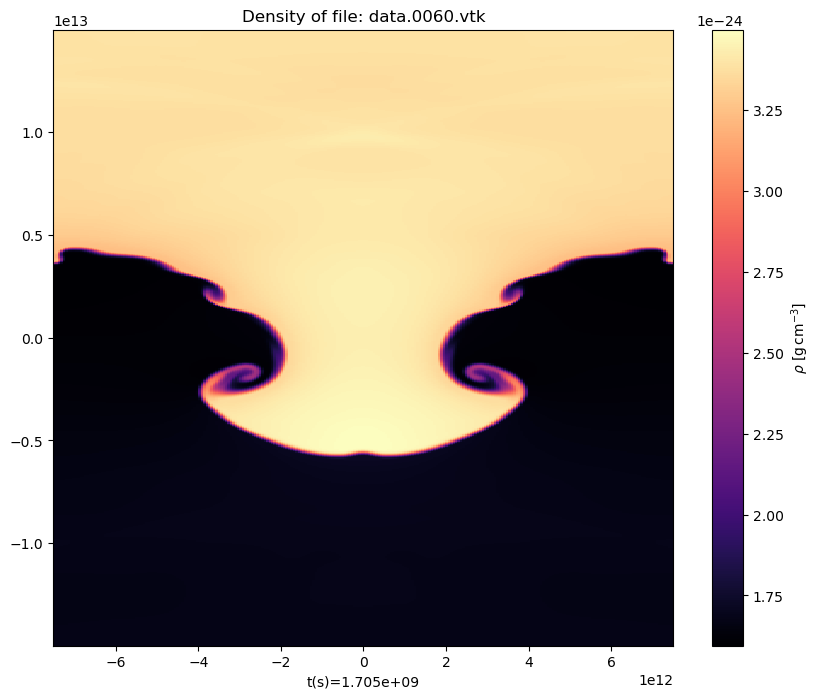

In [93]:
# create the values of x and y in 2d
x_60=np.linspace(mesh_60.bounds[0],mesh_60.bounds[1],mesh_60.dimensions[0]-1)
y_60=np.linspace(mesh_60.bounds[2],mesh_60.bounds[3],mesh_60.dimensions[1]-1)
## convert the x and y in 2d
x_2d_60,y_2d_60=np.meshgrid(x_60,y_60)
#resize the values to make the 2D plot
density_60=parameters_60['rho']
rho_2d_60=density_60.reshape(mesh_60.dimensions[1] - 1,mesh_60.dimensions[0] - 1)
plt.figure(figsize=(10, 8))
plt.pcolor(x_2d_60,y_2d_60,rho_2d_60,cmap='magma')
plt.colorbar(label=r'$\rho\ [\mathrm{g\,cm^{-3}}]$')
plt.title(f'Density of file: {file_60}')
plt.xlabel(f"t(s)={(parameters_60['time']):.3e}")
plt.show()

- A figure showing the entropy, $S = \frac{P}{\rho^\gamma}$.
* $\gamma=\frac{5}{3}$

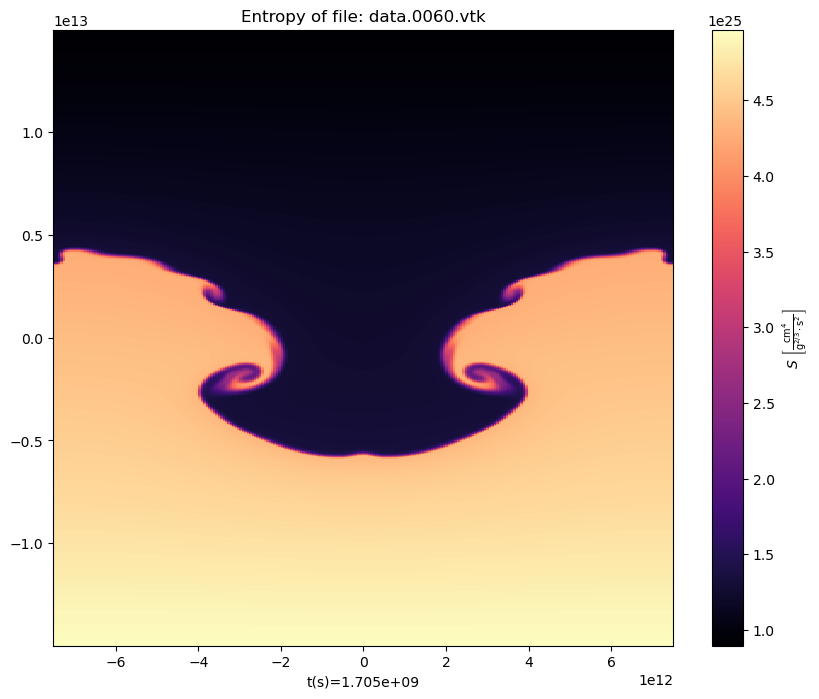

In [94]:
P_60=parameters_60['pressure']
entropy_60=P_60/(density_60**(5/3))
entropy_2d_60=entropy_60.reshape(mesh_60.dimensions[1] - 1,mesh_60.dimensions[0] - 1)

plt.figure(figsize=(10, 8))
plt.pcolor(x_2d_60,y_2d_60,entropy_2d_60,cmap='magma')
plt.colorbar(label=r'$S$ $\left[ \frac{\mathrm{cm}^4}{\mathrm{g}^{2/3} \cdot \mathrm{s}^2} \right]$')
plt.title(f'Entropy of file: {file_60}')
plt.xlabel(f"t(s)={(parameters_60['time']):.3e}")
plt.show()



- A figure showing showing the gas velocity, $\vec{v}=\vec{v}_x+\vec{v}_y$.

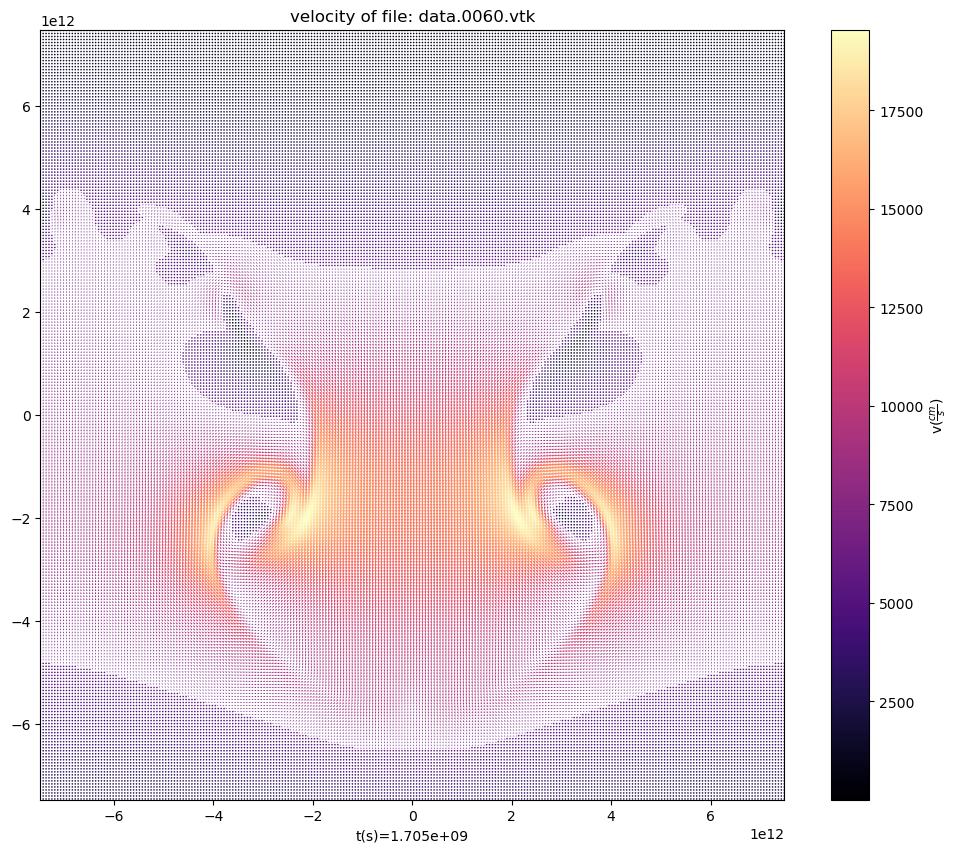

In [95]:

## for velocities 
vx_60=parameters_60['vx']
vy_60=parameters_60['vy']
# transfor to 2d
vx_60_2d=vx_60.reshape(mesh_60.dimensions[1] - 1,mesh_60.dimensions[0] - 1)
vy_60_2d=vy_60.reshape(mesh_60.dimensions[1] - 1,mesh_60.dimensions[0] - 1)
# calculate the modulus of velocity
mod_60=np.sqrt(vx_60_2d**2 + vy_60_2d**2)
# the plot of vector for velocity
plt.figure(figsize=(12, 10))
z=plt.quiver(x_2d_60,y_2d_60,vx_60_2d,vy_60_2d,mod_60,cmap='magma')
plt.colorbar(z,label=r'v($ \frac{cm}{s}$)')
plt.xlim(mesh_60.bounds[0],mesh_60.bounds[1])
plt.ylim(mesh_60.bounds[0],mesh_60.bounds[1])
plt.title(f'velocity of file: {file_60}')
plt.xlabel(f"t(s)={(parameters_60['time']):.3e}")
plt.ylim()
plt.show()




- A figure showing the tracer, $h_{gas}\equiv \rm tr1$, of the heavier gas.

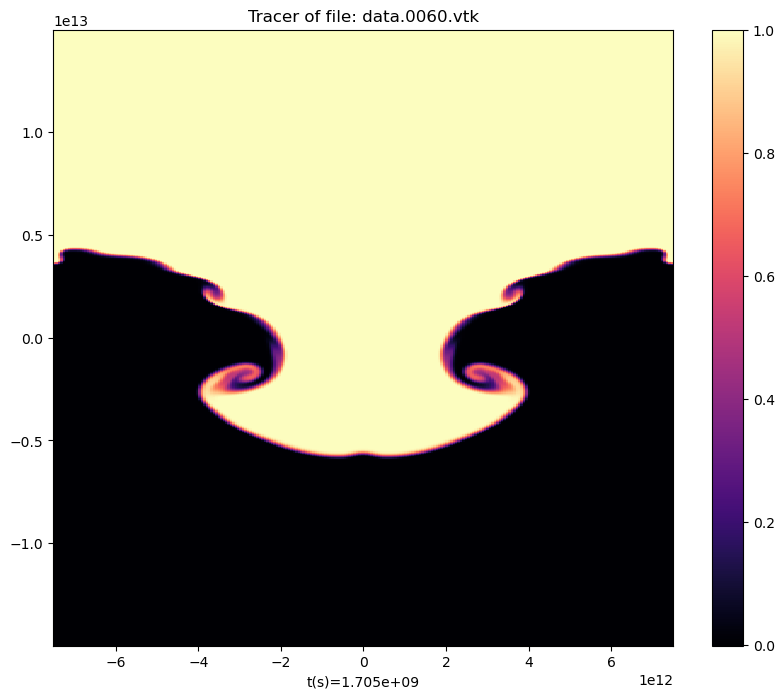

In [96]:
h_gas_60=parameters_60['tracer']
h_gas_60_2d=h_gas_60.reshape(mesh_60.dimensions[1] - 1,mesh_60.dimensions[0] - 1)
plt.figure(figsize=(10, 8))
plt.pcolor(x_2d_60,y_2d_60,h_gas_60_2d,cmap='magma')
plt.colorbar()
plt.title(f'Tracer of file: {file_60}')
plt.xlabel(f"t(s)={(parameters_60['time']):.3e}")
plt.show()







**Notes:** Choose different perceptually-uniform colour schemes for each of the above quantities, and fix the colour bar limits. Add the correct time stamp in CGS units to each map. Since these are high-resolution models, one way to improve the visualisation of 2D vector fields is to interpolate them into a coarser grid.

# Part B: Analysis of the thermodynamical quantities

## (e) Create a set of Python functions that loop over all the VTK simulation files and returns maps of the density field $\rho$, the entropy $S = \frac{P}{\rho^\gamma}$, and also histograms of the density field and entropy in CGS units for all times, into a folder called **"output_data"**.



In [97]:

    
def simulation_files(name):
    os.makedirs('output_data',exist_ok=True)
    os.chdir('output_data')# get in folder
    


    mesh,parameters=read_datos_vtk(name)

    x=np.linspace(mesh.bounds[0],mesh.bounds[1],mesh.dimensions[0]-1)
    y=np.linspace(mesh.bounds[2],mesh.bounds[3],mesh.dimensions[1]-1)
    ## convert the x and y in 2d
    x_2d,y_2d=np.meshgrid(x,y)
    #resize the values to make the 2D plot
    density=parameters['rho']
    rho_2d=density.reshape(mesh.dimensions[1] - 1,mesh.dimensions[0] - 1)

    os.makedirs('density',exist_ok=True)
    os.chdir('density')

    ## first to make the simulation of density 
    plt.figure(figsize=(10, 8))
    plt.pcolor(x_2d,y_2d,rho_2d,cmap='magma')
    plt.colorbar(label=r'$\rho\ [\mathrm{g\,cm^{-3}}]$')
    plt.title(f'Density of file: {name}')
    plt.xlabel(f"t(s)={(parameters['time']):.3e}")
    plt.savefig(name[:-4]+'.png')
    plt.close()
    os.chdir('..')
    ## for make the entropy
    os.makedirs('entropy',exist_ok=True)
    os.chdir('entropy')

    P=parameters['pressure']
    entropy=P/(density**(5/3))
    entropy_2d=entropy.reshape(mesh.dimensions[1] - 1,mesh.dimensions[0] - 1)

    plt.figure(figsize=(10, 8))
    plt.pcolor(x_2d,y_2d,entropy_2d,cmap='magma')
    plt.colorbar(label=r'$S$ $\left[ \frac{\mathrm{cm}^4}{\mathrm{g}^{2/3} \cdot \mathrm{s}^2} \right]$')
    plt.title(f'Entropy of file: {name}')
    plt.xlabel(f"t(s)={(parameters['time']):.3e}")
    plt.savefig(name[:-4]+'.png')
    plt.close()


    os.chdir('..')


    #histograms
    #density
    os.makedirs('Histogram of density',exist_ok=True)
    os.chdir('Histogram of density')

    plt.figure(figsize=(10, 8))
    plt.hist(density,color='red',label=f"t(s)={(parameters['time']):.3e}")
    plt.title(f'Histograms of Density of file: {name}')
    plt.xlabel('dyn cm^2')
    plt.ylabel('frecuency')
    plt.legend()
    plt.savefig(name[:-4]+'.png')
    plt.close()

    os.chdir('..')
    # Entropy
    os.makedirs('Histogram of Entropy',exist_ok=True)
    os.chdir('Histogram of Entropy')

    plt.figure(figsize=(10, 8))
    plt.hist(entropy,color='blue',label=f"t(s)={(parameters['time']):.3e}")
    plt.title(f'Histograms of Entropy of file: {name}')
    plt.xlabel('entropy')
    plt.ylabel('frecuency')
    plt.legend()
    plt.savefig(name[:-4]+'.png')
    plt.close()

    os.chdir('..')


    os.chdir('..') #get out of folder


here create all imagenes in each folder

In [ ]:
for i in range(len(time_vtk)):
    name_n=f'data.{i:04d}.vtk'
    simulation_files(name_n)

## (f) Briefly describe: what happens with the density and entropy fields as time progresses? Do they follow any statistical distributions at late times?

As can be seen in the images, the distributions travel from equilibrium to the point where the waves in the fluid begin to tend to take on mushroom shapes. Between both forms of the graphs, they tend to be the same figures, being in fact the same graphs, since one is a function of the other. The statistical distribution that can be seen from the beginning resembles a Gaussian bell curve, but very soon it begins to deform and loses the characteristics of a function, and I opted for a mushroom shape.

# Part C: Time evolution

## (g) Create a set of Python functions that loops over all the VTK simulation files, computes the following quantities in CGS units for each time:

- the average gas temperature, $\overline T$, (**Hint:** the temperature in each grid cell can be calculated using the equation of state for ideal gases, i.e., $p=\frac{\rho\,k_B\,T}{\mu\,m_u}$, where $k_B$ is the Boltzmann constant, $m_u$ is the atomic mass unit, and $\mu=0.6$ is the mean particle mass in the gas.)



In [99]:
def average_T(name):
    mesh,parameters=read_datos_vtk(name)
    density=parameters['rho']
    pressuere=parameters['pressure']
    m=1.660539e-24 #g
    k=1.380649e-16
    T=(pressuere*0.6*m)/(density*k)
    array_tem_sol=[parameters['time'],np.mean(T)] ## time(s),Temperature mean from all system in this file
    return array_tem_sol

T_mean_all_data=[]
for i in range(len(time_vtk)):
    name_n=f'data.{i:04d}.vtk'
    T_mean_all_data.append(average_T(name_n))

print(T_mean_all_data)




[[np.float64(0.0), np.float64(32.473534546622766)], [np.float64(28305845.919999998), np.float64(32.465616413208785)], [np.float64(56442748.559999995), np.float64(32.46461995770794)], [np.float64(85012503.84), np.float64(32.46334341651434)], [np.float64(113582274.08), np.float64(32.462106893902906)], [np.float64(142093924.72), np.float64(32.46104628038834)], [np.float64(170132450.4), np.float64(32.460401049797625)], [np.float64(198646509.6), np.float64(32.45989374097128)], [np.float64(227166552.8), np.float64(32.459465332534904)], [np.float64(255703650.4), np.float64(32.459271751222474)], [np.float64(284236260.0), np.float64(32.45981860269801)], [np.float64(312347296.8), np.float64(32.46108778641825)], [np.float64(340890378.4), np.float64(32.46096552136182)], [np.float64(369432712.0), np.float64(32.460726940589645)], [np.float64(397553622.4), np.float64(32.46062396391851)], [np.float64(426095956.0), np.float64(32.46048956798297)], [np.float64(454644124.0), np.float64(32.46077912371134)]

In [100]:
#convert the array to numpy arrar
T_mean_all_data=np.array(T_mean_all_data)

- the average entropy, $\overline S$, where $S = \frac{P}{\rho^\gamma}$.

In [101]:
def average_S(name):
    mesh,parameters=read_datos_vtk(name)
    density=parameters['rho']
    pressuere=parameters['pressure']
    S=(pressuere)/(density**(5/3))
    array_tem_sol=[parameters['time'],np.mean(S)] ## time(s),Temperature mean from all system in this file
    return array_tem_sol

S_mean_all_data=[]
for i in range(len(time_vtk)):
    name_n=f'data.{i:04d}.vtk'
    S_mean_all_data.append(average_S(name_n))

print(S_mean_all_data)

[[np.float64(0.0), np.float64(2.864903075411532e+25)], [np.float64(28305845.919999998), np.float64(2.862821846153476e+25)], [np.float64(56442748.559999995), np.float64(2.862624795457324e+25)], [np.float64(85012503.84), np.float64(2.8623819317008646e+25)], [np.float64(113582274.08), np.float64(2.862141672669656e+25)], [np.float64(142093924.72), np.float64(2.861933604195337e+25)], [np.float64(170132450.4), np.float64(2.8618263869781975e+25)], [np.float64(198646509.6), np.float64(2.861753160414303e+25)], [np.float64(227166552.8), np.float64(2.8616947231652052e+25)], [np.float64(255703650.4), np.float64(2.8616806392561375e+25)], [np.float64(284236260.0), np.float64(2.861962788309996e+25)], [np.float64(312347296.8), np.float64(2.862556707229204e+25)], [np.float64(340890378.4), np.float64(2.862532760577949e+25)], [np.float64(369432712.0), np.float64(2.8624911106067886e+25)], [np.float64(397553622.4), np.float64(2.8624802700170226e+25)], [np.float64(426095956.0), np.float64(2.8624546235208767

In [102]:
S_mean_all_data=np.array(S_mean_all_data)

- the average kinetic energy density of the gas, $\overline E_k$, where $E_k = \frac{1}{2}\rho\,v^2$.

In [103]:
def average_E(name):
    mesh,parameters=read_datos_vtk(name)
    density=parameters['rho']
    vx=parameters['vx']
    vy=parameters['vy']
    V=0.5*density*((vx**2)+(vy**2))
    array_tem_sol=[parameters['time'],np.mean(V)] ## time(s),Temperature mean from all system in this file
    return array_tem_sol

E_mean_all_data=[]
for i in range(len(time_vtk)):
    name_n=f'data.{i:04d}.vtk'
    E_mean_all_data.append(average_E(name_n))

print(E_mean_all_data)

[[np.float64(0.0), np.float64(8.339949246553599e-20)], [np.float64(28305845.919999998), np.float64(4.592179949825926e-20)], [np.float64(56442748.559999995), np.float64(4.7828329092218676e-20)], [np.float64(85012503.84), np.float64(4.813501929391568e-20)], [np.float64(113582274.08), np.float64(4.882910404487398e-20)], [np.float64(142093924.72), np.float64(3.9233148700107273e-20)], [np.float64(170132450.4), np.float64(5.0861354983696926e-20)], [np.float64(198646509.6), np.float64(5.027514330860307e-20)], [np.float64(227166552.8), np.float64(4.1863132005788346e-20)], [np.float64(255703650.4), np.float64(5.0858384702685404e-20)], [np.float64(284236260.0), np.float64(5.733151905683853e-20)], [np.float64(312347296.8), np.float64(5.869224042574879e-20)], [np.float64(340890378.4), np.float64(6.307364964585566e-20)], [np.float64(369432712.0), np.float64(7.855485549505308e-20)], [np.float64(397553622.4), np.float64(6.867665251477273e-20)], [np.float64(426095956.0), np.float64(7.520754238029403e-

In [104]:
E_mean_all_data=np.array(E_mean_all_data)

In [105]:
parameters_60.keys()

dict_keys(['rho', 'vx', 'vy', 'pressure', 'time', 'tracer'])

- the average sound speed of the heavier gas, $\overline c_{s,h}$, where $c_{s,h}=h_{gas}\,\sqrt{\gamma\,\frac{p}{\rho}}$

In [106]:
def average_c(name):
    mesh,parameters=read_datos_vtk(name)
    density=parameters['rho']
    pressure=parameters['pressure']
    h=parameters['tracer']
    V=h*np.sqrt((5/3)*(pressure/density))
    array_tem_sol=[parameters['time'],np.mean(V)] ## time(s),Temperature mean from all system in this file
    return array_tem_sol

c_mean_all_data=[]
for i in range(len(time_vtk)):
    name_n=f'data.{i:04d}.vtk'
    c_mean_all_data.append(average_c(name_n))

print(c_mean_all_data)

[[np.float64(0.0), np.float64(32220.661018199113)], [np.float64(28305845.919999998), np.float64(32265.662560377146)], [np.float64(56442748.559999995), np.float64(32268.775301073016)], [np.float64(85012503.84), np.float64(32273.311073451165)], [np.float64(113582274.08), np.float64(32277.679946984994)], [np.float64(142093924.72), np.float64(32281.21225684012)], [np.float64(170132450.4), np.float64(32284.14295385722)], [np.float64(198646509.6), np.float64(32286.819760774597)], [np.float64(227166552.8), np.float64(32289.206590620764)], [np.float64(255703650.4), np.float64(32291.779670903234)], [np.float64(284236260.0), np.float64(32289.816488729284)], [np.float64(312347296.8), np.float64(32282.83909593754)], [np.float64(340890378.4), np.float64(32285.34955020038)], [np.float64(369432712.0), np.float64(32288.48066843899)], [np.float64(397553622.4), np.float64(32290.797036422908)], [np.float64(426095956.0), np.float64(32293.423474239888)], [np.float64(454644124.0), np.float64(32293.503309389

In [107]:
c_mean_all_data=np.array(c_mean_all_data)

and returns:

- a CSV file with 5 columns, time on the first column, and the above quantities in the next ones. The CSV file should be named **"stats.csv"** saved into the folder called **"output_data"**.

In [108]:
save_file_pandas=pd.DataFrame({'time':c_mean_all_data[:,0],'gas temperature':T_mean_all_data[:,1],'Entropy':S_mean_all_data[:,1],'Kinetic Energy':E_mean_all_data[:,1],'sound speed':c_mean_all_data[:,1]})
save_file_pandas

,time,gas temperature,Entropy,Kinetic Energy,sound speed
0,0.000000e+00,32.473535,2.864903e+25,8.339949e-20,32220.661018
1,2.830585e+07,32.465616,2.862822e+25,4.592180e-20,32265.662560
2,5.644275e+07,32.464620,2.862625e+25,4.782833e-20,32268.775301
3,8.501250e+07,32.463343,2.862382e+25,4.813502e-20,32273.311073
4,1.135823e+08,32.462107,2.862142e+25,4.882910e-20,32277.679947
...,...,...,...,...,...
96,2.728527e+09,32.040629,2.836068e+25,2.837639e-16,34613.638570
97,2.757106e+09,32.015219,2.833406e+25,2.915093e-16,34747.548350
98,2.785525e+09,31.986531,2.829820e+25,2.992594e-16,34896.534800
99,2.813907e+09,31.958003,2.826991e+25,3.067722e-16,35042.619541


In [109]:

os.chdir('output_data')
save_file_pandas.to_csv('stats.csv',index=False)
os.chdir('..')




## (h) Create a Python function that reads in the CSV file created in (g) and returns (i.e. shows or saves) high-quality labeled figures of each of the above-computed quantities versus time, into the folder called **"output_data"**. 

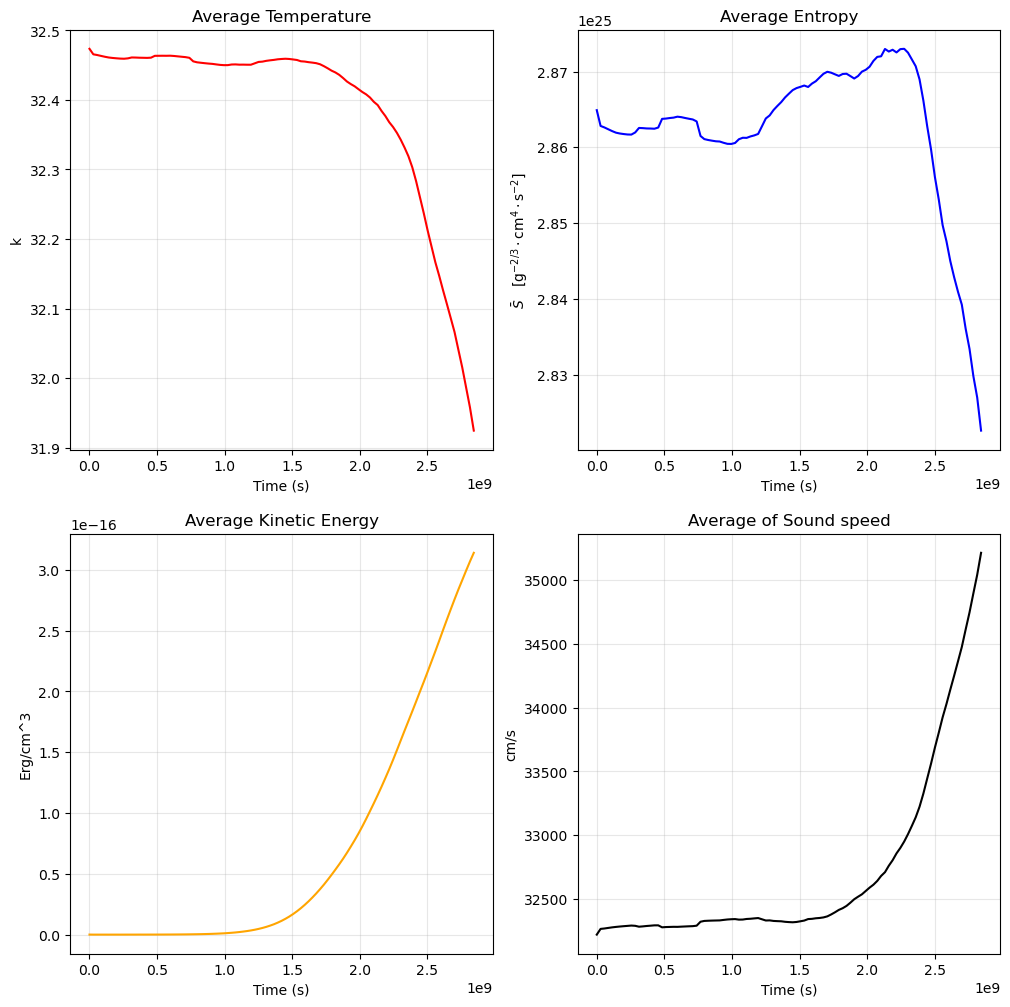

In [110]:
os.chdir('output_data')

stats=pd.DataFrame(pd.read_csv('stats.csv'))
plt.figure(figsize=(12,12))

plt.subplot(2,2,1)
plt.plot(stats['time'],stats['gas temperature'],color='red')
plt.grid(True,alpha=0.3)
plt.title('Average Temperature')
plt.xlabel('Time (s)')
plt.ylabel('k')

plt.subplot(2,2,2)
plt.plot(stats['time'],stats['Entropy'],color='blue')
plt.grid(True,alpha=0.3)
plt.title('Average Entropy')
plt.xlabel('Time (s)')
plt.ylabel(r'$\bar{S} \quad [\mathrm{g}^{-2/3} \cdot \mathrm{cm}^{4} \cdot \mathrm{s}^{-2}]$')

plt.subplot(2,2,3)
plt.plot(stats['time'],stats['Kinetic Energy'],color='orange')
plt.grid(True,alpha=0.3)
plt.title('Average Kinetic Energy')
plt.xlabel('Time (s)')
plt.ylabel('Erg/cm^3')

plt.subplot(2,2,4)
plt.plot(stats['time'],stats['sound speed'],color='black')
plt.grid(True,alpha=0.3)
plt.title('Average of Sound speed')
plt.xlabel('Time (s)')
plt.ylabel('cm/s')

plt.show()

os.chdir('..')

# Part D: Animations and steady state

## (i) Briefly describe: What happens to the average kinetic energy and the average sound speed of the heavier gas as time progresses? Does the flow reach steady state? 

As can be seen in the images generated in the previous activity, the two parameters do not reach equilibrium after a period of time, as can be seen in the simulation. It can be seen that at the beginning they remain constant but then grow exponentially.



## (j) Create a Python function that returns movies showing the time evolution of the entropy maps computed in (d) and the average values of the entropy calculated in (g). The movies should be saved into the folder called **"output_data"**. 

In [111]:
from IPython import display
import glob
from PIL import Image


#### density
def grif_simulation(folder,name_final):

    os.chdir('output_data')

    imagen_den=f'./{folder}/data.****.png'
    imagen_den_out=f'{name_final}'
    ## colect the imagens
    ima=(Image.open(f) for f in sorted(glob.glob(imagen_den)))
    im=next(ima)

    im.save(fp=imagen_den_out,format='GIF',append_images=ima,save_all=True,duration=100,loop=0)
    display.Image(open(f'{name_final}','rb').read())

    os.chdir('..')

grif_simulation('density','animation_density.gif') # generate a gif in folder output_data of density
grif_simulation('entropy','animation_entropy.gif') # generate a gif in folder output_data of density

grif_simulation('Histogram of density','animation_histogram_density.gif') # generate a gif in folder output_data of density
grif_simulation('Histogram of Entropy','animation_histogram_entropy.gif') # generate a gif in folder output_data of density






